In [50]:
import pandas as pd

df = pd.read_csv('destinations.csv', encoding="latin1")
df.shape

(150, 11)

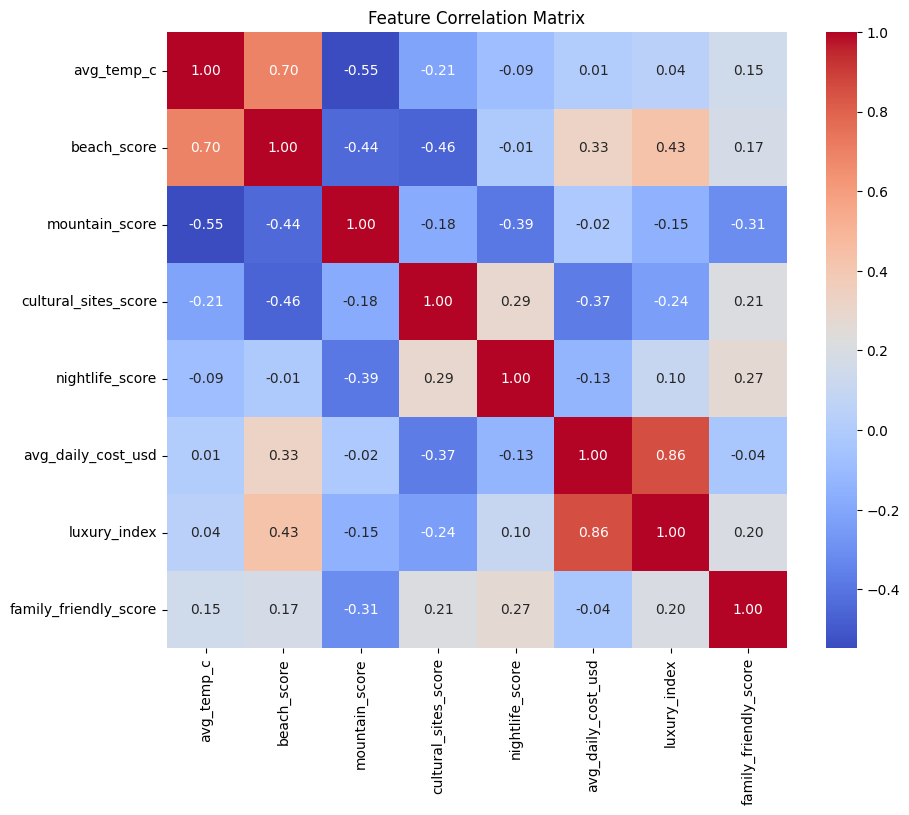

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['city','country','travel_style']).corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

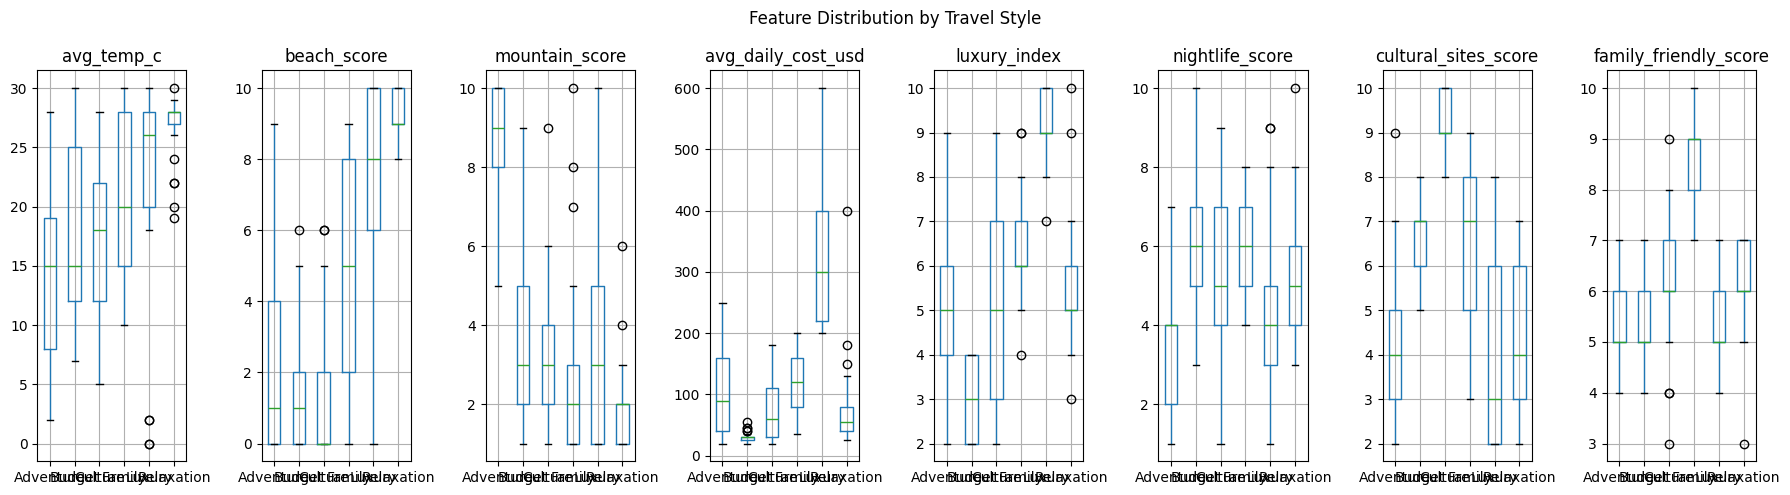

In [52]:
features = ['avg_temp_c', 'beach_score', 'mountain_score', 
            'avg_daily_cost_usd', 'luxury_index', 'nightlife_score', 'cultural_sites_score', 'family_friendly_score']

fig, axes = plt.subplots(1, len(features), figsize=(18, 5))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='travel_style', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Feature Distribution by Travel Style')
plt.tight_layout()
plt.show()

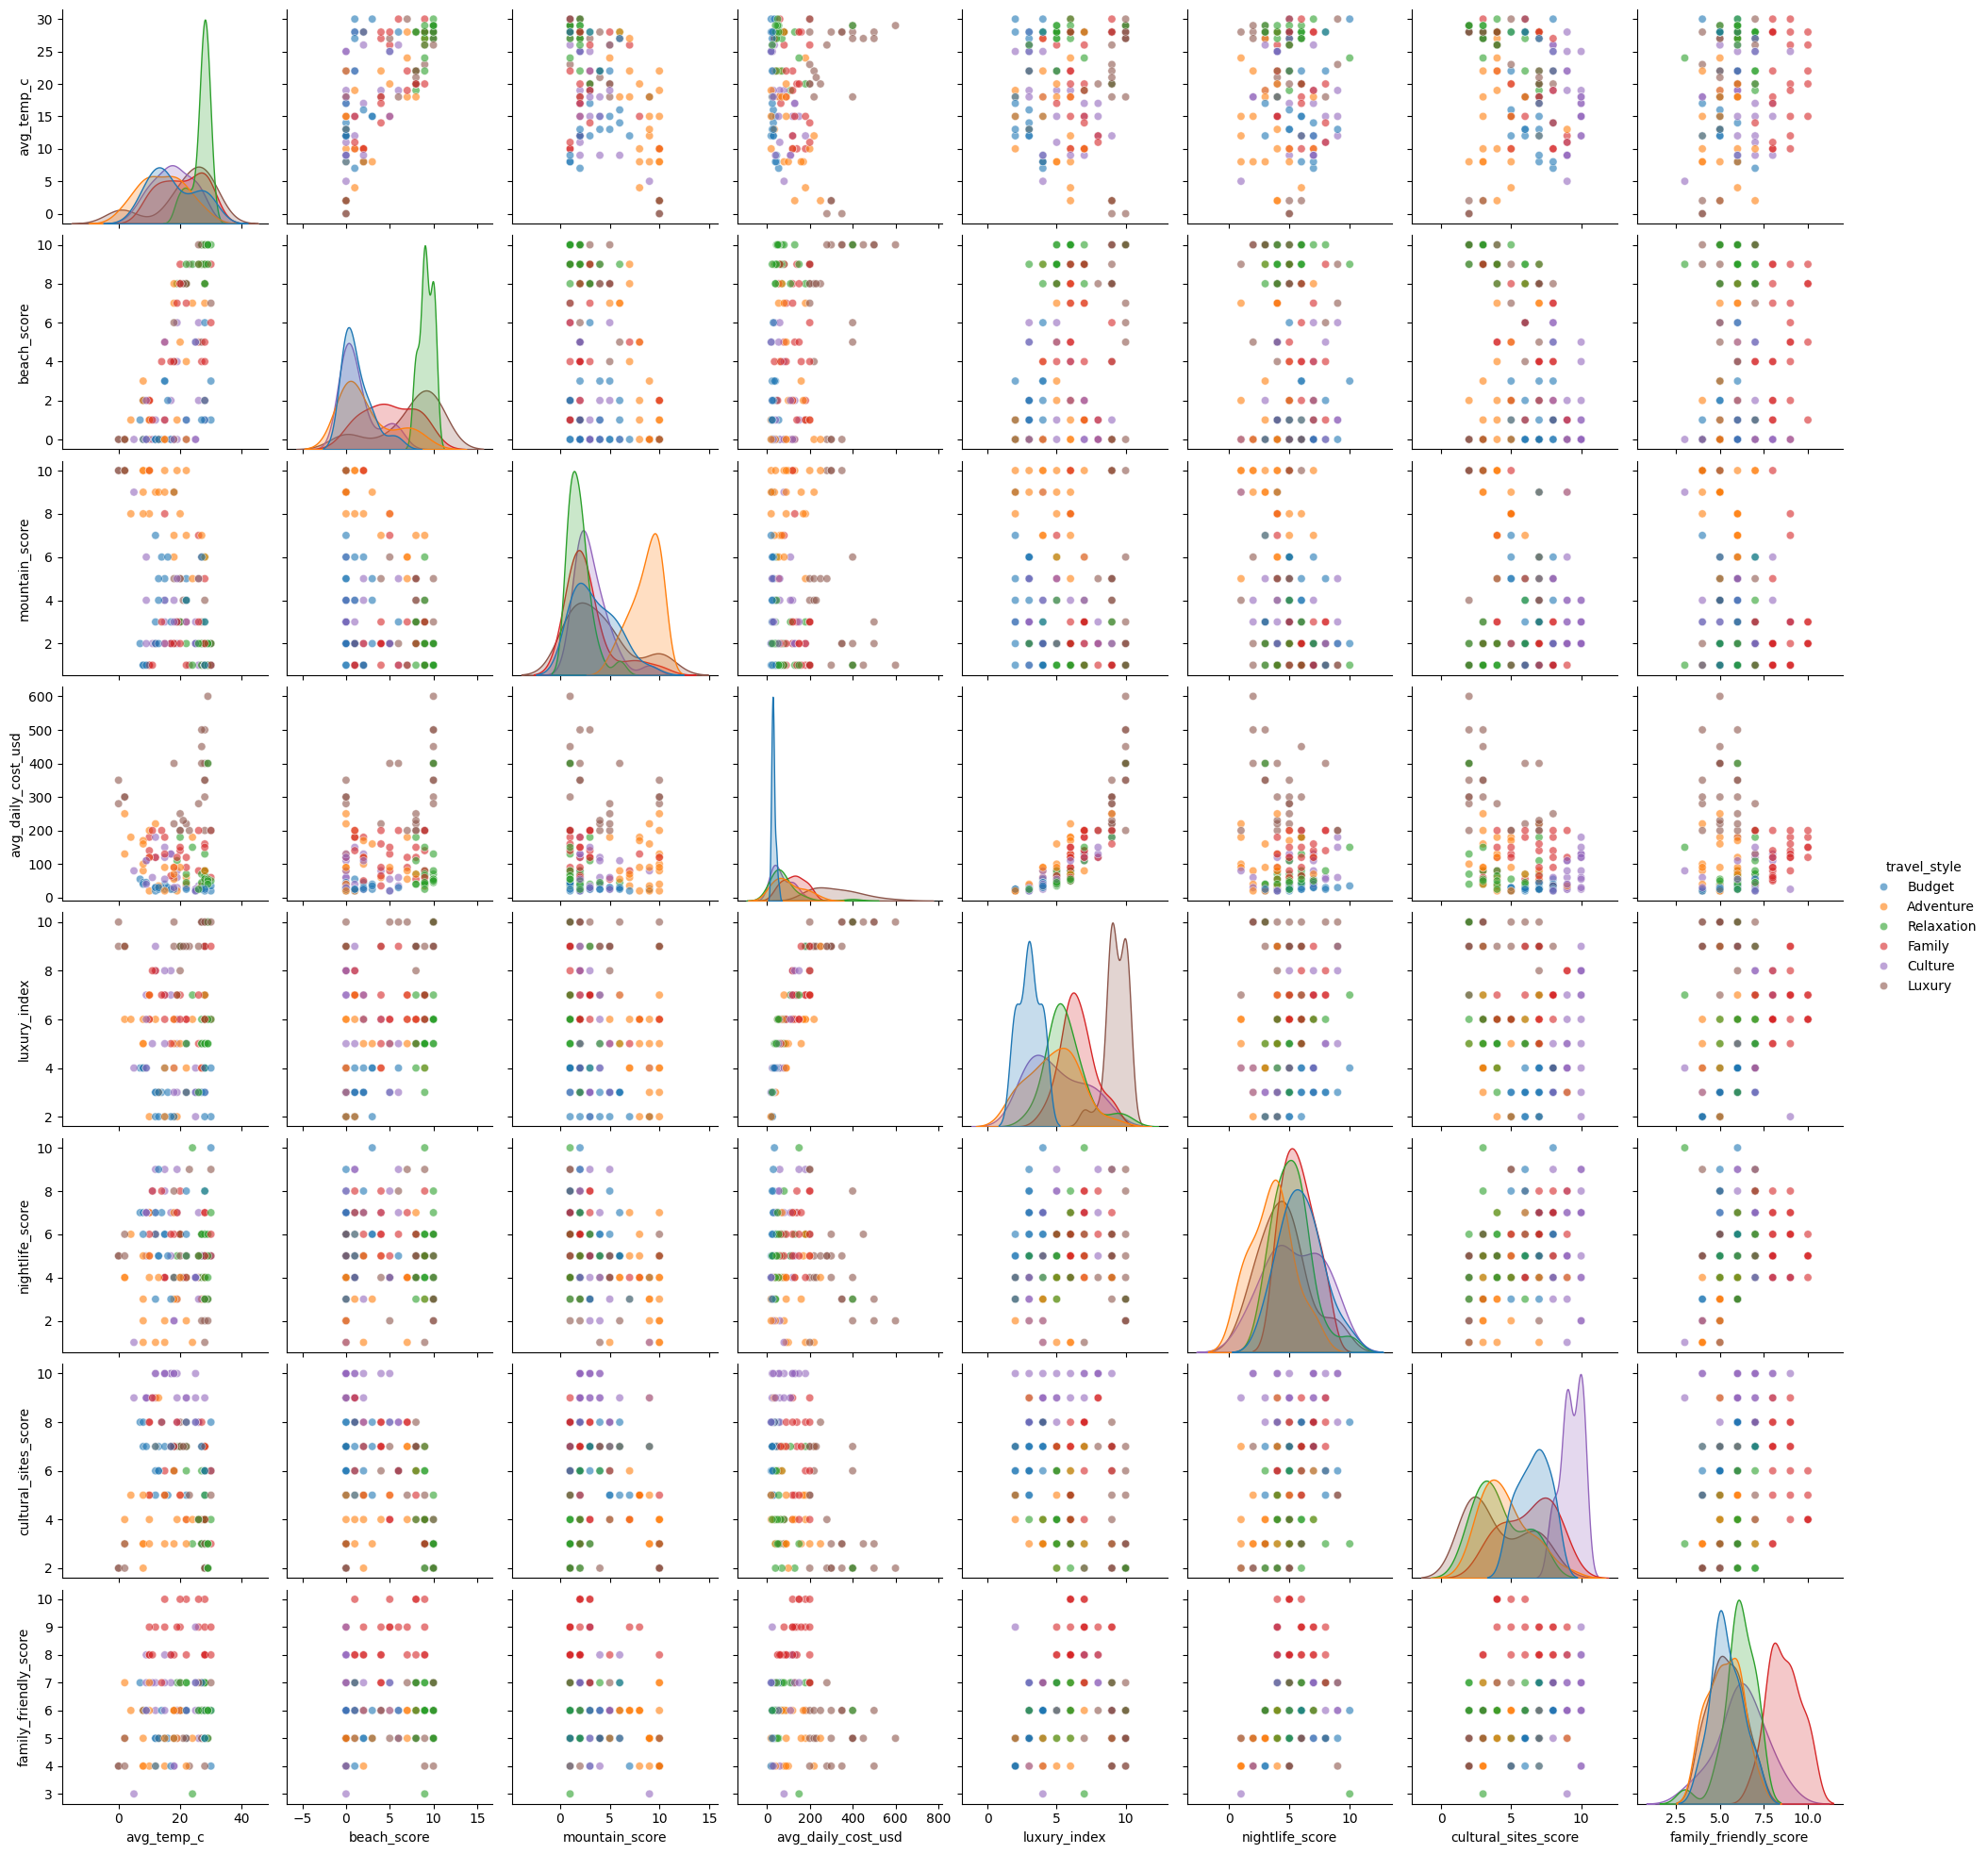

In [53]:
import seaborn as sns
sns.pairplot(df.drop(columns=['city','country']), 
             hue='travel_style', 
             vars=['avg_temp_c', 'beach_score', 'mountain_score', 
            'avg_daily_cost_usd', 'luxury_index', 'nightlife_score', 'cultural_sites_score', 'family_friendly_score'],
             plot_kws={'alpha': 0.6})
plt.show()

In [54]:
print(df['travel_style'].value_counts())


travel_style
Budget        25
Adventure     25
Relaxation    25
Family        25
Culture       25
Luxury        25
Name: count, dtype: int64


In [55]:
import pandas as pd, joblib, csv, datetime as dt, random, numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import classification_report

X = df.drop(columns=['city', 'country', 'travel_style'])
y = df['travel_style']
 
# stratify=y preserves class balance in the test split
# Without this, if Luxury has 8 rows, it might all end up in train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

travel_style
Budget        20
Culture       20
Family        20
Luxury        20
Adventure     20
Relaxation    20
Name: count, dtype: int64
travel_style
Family        5
Culture       5
Luxury        5
Budget        5
Relaxation    5
Adventure     5
Name: count, dtype: int64


In [56]:
SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
 
models = {
  'baseline': DummyClassifier(strategy='most_frequent', random_state=SEED),
  'logreg':   Pipeline([('scaler', StandardScaler()),
                        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
  'rf':       Pipeline([('clf', RandomForestClassifier(random_state=SEED, class_weight='balanced'))]),
  'gb':       Pipeline([('clf', GradientBoostingClassifier(random_state=SEED))]),
}
 
rows = []
for name, pipe in models.items():
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc_ovr')
    pres = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='precision_macro')
    rec = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall_macro')
    rows.append({'model': name, 'f1_mean': f1.mean(), 'f1_std': f1.std(),
                 'acc_mean': acc.mean(), 'acc_std': acc.std(),
                 'auc_mean': auc.mean(), 'auc_std': auc.std(),
                 'pres_mean': pres.mean(), 'pres_std': pres.std(),
                 'rec_mean': rec.mean(), 'rec_std': rec.std(),
                 'timestamp': dt.datetime.utcnow().isoformat()})

c:\Users\rasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rasha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [57]:
results_df = pd.DataFrame(rows)
print("\n--- Full Results Table ---")
print(results_df.to_string(index=False))


--- Full Results Table ---
   model  f1_mean   f1_std  acc_mean  acc_std  auc_mean  auc_std  pres_mean     pres_std  rec_mean  rec_std                  timestamp
baseline 0.047619 0.000000  0.166667 0.000000  0.500000 0.000000   0.027778 3.469447e-18  0.166667 0.000000 2026-04-28T21:02:27.622783
  logreg 0.802619 0.063361  0.808333 0.056519  0.974583 0.018606   0.836111 4.499657e-02  0.808333 0.056519 2026-04-28T21:02:28.168697
      rf 0.802937 0.068695  0.808333 0.067700  0.966875 0.019459   0.830556 7.330387e-02  0.808333 0.067700 2026-04-28T21:02:32.273025
      gb 0.792222 0.068057  0.800000 0.066667  0.947500 0.034167   0.833333 6.228667e-02  0.800000 0.066667 2026-04-28T21:02:48.439215


In [61]:
from sklearn.model_selection import GridSearchCV

# RF param grid
rf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 5, 10, 15],
    'clf__min_samples_split': [2, 5, 10],
}

# GB param grid
gb_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.2],
}

grids = {
    'rf_tuned': (models['rf'], rf_params),
    'gb_tuned': (models['gb'], gb_params),
}

tuned_rows = []
tuned_estimators = {}
for name, (pipe, params) in grids.items():
    grid = GridSearchCV(
        pipe, params,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    tuned_estimators[name] = grid.best_estimator_
    
    tuned_rows.append({
        'model': name,
        'f1_mean': round(grid.best_score_, 4),
        'f1_std': round(grid.cv_results_['std_test_score'][grid.best_index_], 4),
        'best_params': str(grid.best_params_),
        'timestamp': dt.datetime.utcnow().isoformat()
    })

print("\n--- Tuned Results ---")
for r in tuned_rows:
    print(f"{r['model']:10s} | F1: {r['f1_mean']:.4f} ± {r['f1_std']:.4f} | Params: {r['best_params']}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


C:\Users\rasha\AppData\Local\Temp\ipykernel_21656\972904765.py:40: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': dt.datetime.utcnow().isoformat()


Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Tuned Results ---
rf_tuned   | F1: 0.8204 ± 0.0742 | Params: {'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}
gb_tuned   | F1: 0.8221 ± 0.0798 | Params: {'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__n_estimators': 100}


C:\Users\rasha\AppData\Local\Temp\ipykernel_21656\972904765.py:40: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': dt.datetime.utcnow().isoformat()


In [62]:
winner = tuned_estimators['rf_tuned']
winner.fit(X_train, y_train)
print(classification_report(y_test, winner.predict(X_test)))

              precision    recall  f1-score   support

   Adventure       1.00      1.00      1.00         5
      Budget       1.00      1.00      1.00         5
     Culture       1.00      0.80      0.89         5
      Family       0.83      1.00      0.91         5
      Luxury       1.00      1.00      1.00         5
  Relaxation       1.00      1.00      1.00         5

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



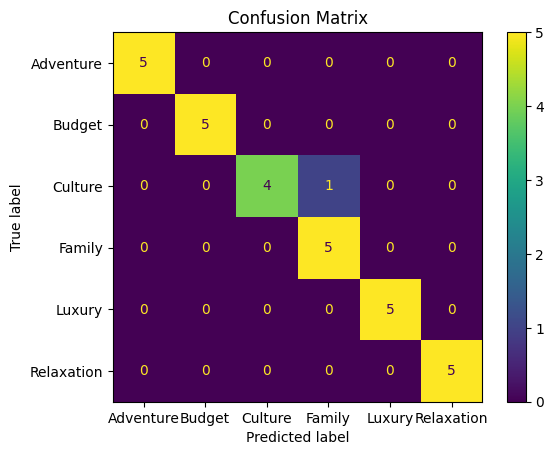

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

winner.fit(X_train, y_train)
ypred = winner.predict(X_test)

cm = ConfusionMatrixDisplay.from_predictions(y_test, ypred)
plt.title('Confusion Matrix')
plt.show()